In [ ]:
# ============================================================
# KERNEL 1 — Setup & Download Dataset from Kaggle
# ============================================================

# Step 1: Install Kaggle API
!pip install kaggle -q

# Step 2: Upload your kaggle.json API key
from google.colab import files
files.upload()  # Upload kaggle.json here when prompted

# Step 3: Move it to the right place so Kaggle API can find it
import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
!mv kaggle.json /root/.config/kaggle/kaggle.json
!chmod 600 /root/.config/kaggle/kaggle.json

# Step 4: Download the dataset
!kaggle datasets download -d kaushikyh/indian-sign-language-words-with-landmarks

# Step 5: Unzip it
!unzip -q indian-sign-language-words-with-landmarks.zip -d /content/ISL_dataset

# Step 6: Confirm what's inside
!ls /content/ISL_dataset

KeyboardInterrupt: 

In [ ]:
# Quick peek inside the dataset folder
import os

for root, dirs, files in os.walk('/content/ISL_dataset/ProcessedData_vivit'):
    level = root.replace('/content/ISL_dataset/ProcessedData_vivit', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # show files only up to 2 levels deep
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # show max 5 files per folder
            print(f'{subindent}{file}')
        if len(files) > 5:
            print(f'{subindent}... and {len(files) - 5} more files')

ProcessedData_vivit/
  month/
    MVI_4632.MOV
    MVI_4633.MOV
    MVI_5487.MOV
    MVI_5490.MOV
    MVI_5489.MOV
    ... and 6 more files
  pant/
    MVI_4007.MOV
    MVI_3855.MOV
    MVI_4005.MOV
    MVI_5172.MOV
    MVI_3707.MOV
    ... and 14 more files
  yesterday/
    MVI_4625.MOV
    MVI_4624.MOV
    MVI_5481.MOV
    MVI_5038.MOV
    MVI_5480.MOV
    ... and 6 more files
  t_shirt/
    MVI_4882.MOV
    MVI_3705.MOV
    MVI_3850.MOV
    MVI_4002.MOV
    MVI_4883.MOV
    ... and 14 more files
  clothing/
    MVI_3865.MOV
    MVI_3716.MOV
    MVI_4015.MOV
    MVI_5036.MOV
    MVI_3864.MOV
    ... and 14 more files
  blind/
    MVI_9854.MOV
    MVI_9855.MOV
    MVI_9584.MOV
    MVI_9585.MOV
    MVI_9853.MOV
    ... and 3 more files
  dress/
    MVI_4868.MOV
    MVI_5009.MOV
    MVI_4869.MOV
    MVI_3988.MOV
    MVI_3838.MOV
    ... and 14 more files
  expensive/
    MVI_9616.MOV
    MVI_9615.MOV
    MVI_9747.MOV
    MVI_9613.MOV
    MVI_9614.MOV
    ... and 3 more files
  tuesday/


In [ ]:
# ============================================================
# KERNEL 2 — Dataset Exploration
# ============================================================

import os

dataset_path = '/content/ISL_dataset/ProcessedData_vivit'

# Get all classes and count videos per class
class_counts = {}

for word in sorted(os.listdir(dataset_path)):
    word_path = os.path.join(dataset_path, word)
    if os.path.isdir(word_path):
        videos = [f for f in os.listdir(word_path) if f.endswith('.MOV')]
        class_counts[word] = len(videos)

# Print summary
print(f"Total classes (words): {len(class_counts)}")
print(f"Total videos         : {sum(class_counts.values())}")
print(f"Min videos in a class: {min(class_counts.values())} ({min(class_counts, key=class_counts.get)})")
print(f"Max videos in a class: {max(class_counts.values())} ({max(class_counts, key=class_counts.get)})")
print(f"\n{'Word':<20} {'Video Count':>12}")
print("-" * 34)
for word, count in sorted(class_counts.items(), key=lambda x: x[1]):
    print(f"{word:<20} {count:>12}")

Total classes (words): 76
Total videos         : 1166
Min videos in a class: 3 (second)
Max videos in a class: 22 (short)

Word                  Video Count
----------------------------------
second                          3
blind                           8
cheap                           8
curved                          8
deaf                            8
expensive                       8
famous                          8
female                          8
flat                            8
light                           8
loose                           8
sad                             8
ugly                            8
beautiful                       9
afternoon                      11
evening                        11
friday                         11
hour                           11
minute                         11
monday                         11
month                          11
morning                        11
night                          11
saturday                  

In [ ]:
!pip install mediapipe

In [ ]:
# ============================================================
# KERNEL 3 — MediaPipe HolisticLandmarker (New Tasks API)
# ============================================================

import cv2
import mediapipe as mp
import numpy as np
import os
import urllib.request
from tqdm import tqdm

# ---- Config ----
DATASET_PATH = '/content/ISL_dataset/ProcessedData_vivit'
OUTPUT_PATH  = '/content/landmarks'
MAX_FRAMES   = 30
os.makedirs(OUTPUT_PATH, exist_ok=True)

# ---- Download Holistic model ----
MODEL_PATH = '/content/holistic_landmarker.task'
if not os.path.exists(MODEL_PATH):
    print("Downloading holistic model...")
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/holistic_landmarker/holistic_landmarker/float16/latest/holistic_landmarker.task',
        MODEL_PATH
    )
print("✅ Model ready")

# ---- New API Setup ----
BaseOptions         = mp.tasks.BaseOptions
HolisticLandmarker = mp.tasks.vision.HolisticLandmarker
HolisticOptions    = mp.tasks.vision.HolisticLandmarkerOptions
VisionRunningMode  = mp.tasks.vision.RunningMode

options = HolisticOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.IMAGE,
    min_face_detection_confidence=0.5,
    min_pose_detection_confidence=0.5,
    min_hand_landmarks_confidence=0.5
)

# ---- Feature Extraction ----
def extract_keypoints(result):
    # Pose: 33 x 3 = 99
    if result.pose_landmarks:
        pose = np.array([[lm.x, lm.y, lm.z]
                         for lm in result.pose_landmarks]).flatten()
    else:
        pose = np.zeros(33 * 3)

    # Left hand: 21 x 3 = 63
    if result.left_hand_landmarks:
        lh = np.array([[lm.x, lm.y, lm.z]
                       for lm in result.left_hand_landmarks]).flatten()
    else:
        lh = np.zeros(21 * 3)

    # Right hand: 21 x 3 = 63
    if result.right_hand_landmarks:
        rh = np.array([[lm.x, lm.y, lm.z]
                       for lm in result.right_hand_landmarks]).flatten()
    else:
        rh = np.zeros(21 * 3)

    return np.concatenate([pose, lh, rh])  # 225 features

def sample_frames(cap, n=MAX_FRAMES):
    total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total - 1, n, dtype=int)
    frames  = []
    for i in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
    return frames

# ---- Main Loop ----
classes = sorted([d for d in os.listdir(DATASET_PATH)
                  if os.path.isdir(os.path.join(DATASET_PATH, d))])
skipped = 0

with HolisticLandmarker.create_from_options(options) as landmarker:
    for word in tqdm(classes, desc="Processing"):
        word_path = os.path.join(DATASET_PATH, word)
        out_path  = os.path.join(OUTPUT_PATH, word)
        os.makedirs(out_path, exist_ok=True)

        for vid_name in [f for f in os.listdir(word_path) if f.endswith('.MOV')]:
            cap = cv2.VideoCapture(os.path.join(word_path, vid_name))
            if not cap.isOpened():
                skipped += 1
                continue

            frames = sample_frames(cap, MAX_FRAMES)
            cap.release()

            if len(frames) < MAX_FRAMES // 2:
                skipped += 1
                continue

            while len(frames) < MAX_FRAMES:
                frames.append(frames[-1])

            sequence = []
            for frame in frames[:MAX_FRAMES]:
                rgb      = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
                result   = landmarker.detect(mp_image)
                sequence.append(extract_keypoints(result))

            sequence  = np.array(sequence)  # (30, 225)
            save_name = os.path.splitext(vid_name)[0] + '.npy'
            np.save(os.path.join(out_path, save_name), sequence)

print(f"\n✅ Done! Skipped {skipped} videos.")

# Sanity check
s = np.load(os.path.join(OUTPUT_PATH, classes[0],
            os.listdir(os.path.join(OUTPUT_PATH, classes[0]))[0]))
print(f"Sample shape: {s.shape}")  # should be (30, 225)

✅ Model ready


Processing: 100%|██████████| 76/76 [40:11<00:00, 31.73s/it]


✅ Done! Skipped 0 videos.
Sample shape: (30, 225)


In [26]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle

LANDMARKS_PATH = '/content/landmarks'
LANDMARKS_PATH = '/content/landmarks_aug'  # use augmented data

X, y = [], []

classes = sorted([d for d in os.listdir(LANDMARKS_PATH)
                  if os.path.isdir(os.path.join(LANDMARKS_PATH, d))])

for word in classes:
    word_path = os.path.join(LANDMARKS_PATH, word)
    for npy_file in os.listdir(word_path):
        if npy_file.endswith('.npy'):
            seq = np.load(os.path.join(word_path, npy_file))
            X.append(seq)
            y.append(word)

X = np.array(X)
y = np.array(y)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

with open('/content/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

mean = X.mean(axis=(0, 1), keepdims=True)
std  = X.std(axis=(0, 1), keepdims=True) + 1e-8
X_norm = (X - mean) / std

np.save('/content/norm_mean.npy', mean)
np.save('/content/norm_std.npy', std)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Total  : {len(X)}")
print(f"Train  : {X_train.shape}")
print(f"Val    : {X_val.shape}")
print(f"Test   : {X_test.shape}")
print(f"Classes: {len(le.classes_)}")

Total  : 1166
Train  : (816, 30, 225)
Val    : (175, 30, 225)
Test   : (175, 30, 225)
Classes: 76


In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

NUM_CLASSES = len(le.classes_)
TIMESTEPS   = 30
FEATURES    = 225   # MediaPipe landmarks

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(TIMESTEPS, FEATURES)),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 128)        │       181,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 76)             │         9,804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,548 (974.80 KB)

 Trainable params: 249,164 (973.30 KB)

 Non-trainable params: 384 (1.50 KB)

In [28]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weight_dict = dict(enumerate(class_weights))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_model.keras',
                    monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯 Test Accuracy : {test_acc*100:.2f}%")
print(f"📉 Test Loss     : {test_loss:.4f}")

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0133 - loss: 4.5889
Epoch 1: val_accuracy improved from None to 0.04571, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.0233 - loss: 4.5218 - val_accuracy: 0.0457 - val_loss: 4.2590 - learning_rate: 0.0010
Epoch 2/100
23/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0384 - loss: 4.1163
Epoch 2: val_accuracy improved from 0.04571 to 0.08571, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0527 - loss: 4.1013 - val_accuracy: 0.0857 - val_loss: 4.1484 - learning_rate: 0.0010
Epoch 3/100
22/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1215 - loss: 3.7244
Epoch 3: val_accuracy improved from 0.08571 to 0.15429, saving model to /content/best_model.keras

Epoch 3: finished saving model to /content/best_


  TRAINING SET
  Accuracy          : 99.02%
  Macro    F1-Score : 98.77%
  Weighted F1-Score : 99.02%
  Macro    Precision: 98.74%
  Macro    Recall   : 98.96%

  VALIDATION SET
  Accuracy          : 73.14%
  Macro    F1-Score : 69.18%
  Weighted F1-Score : 72.64%
  Macro    Precision: 71.91%
  Macro    Recall   : 70.82%

  TEST SET
  Accuracy          : 70.29%
  Macro    F1-Score : 68.91%
  Weighted F1-Score : 69.15%
  Macro    Precision: 72.85%
  Macro    Recall   : 72.25%

Metric                         Train        Val       Test
---------------------------------------------------------
Accuracy                      99.02%     73.14%     70.29%
Macro F1-Score                98.77%     69.18%     68.91%
Weighted F1-Score             99.02%     72.64%     69.15%


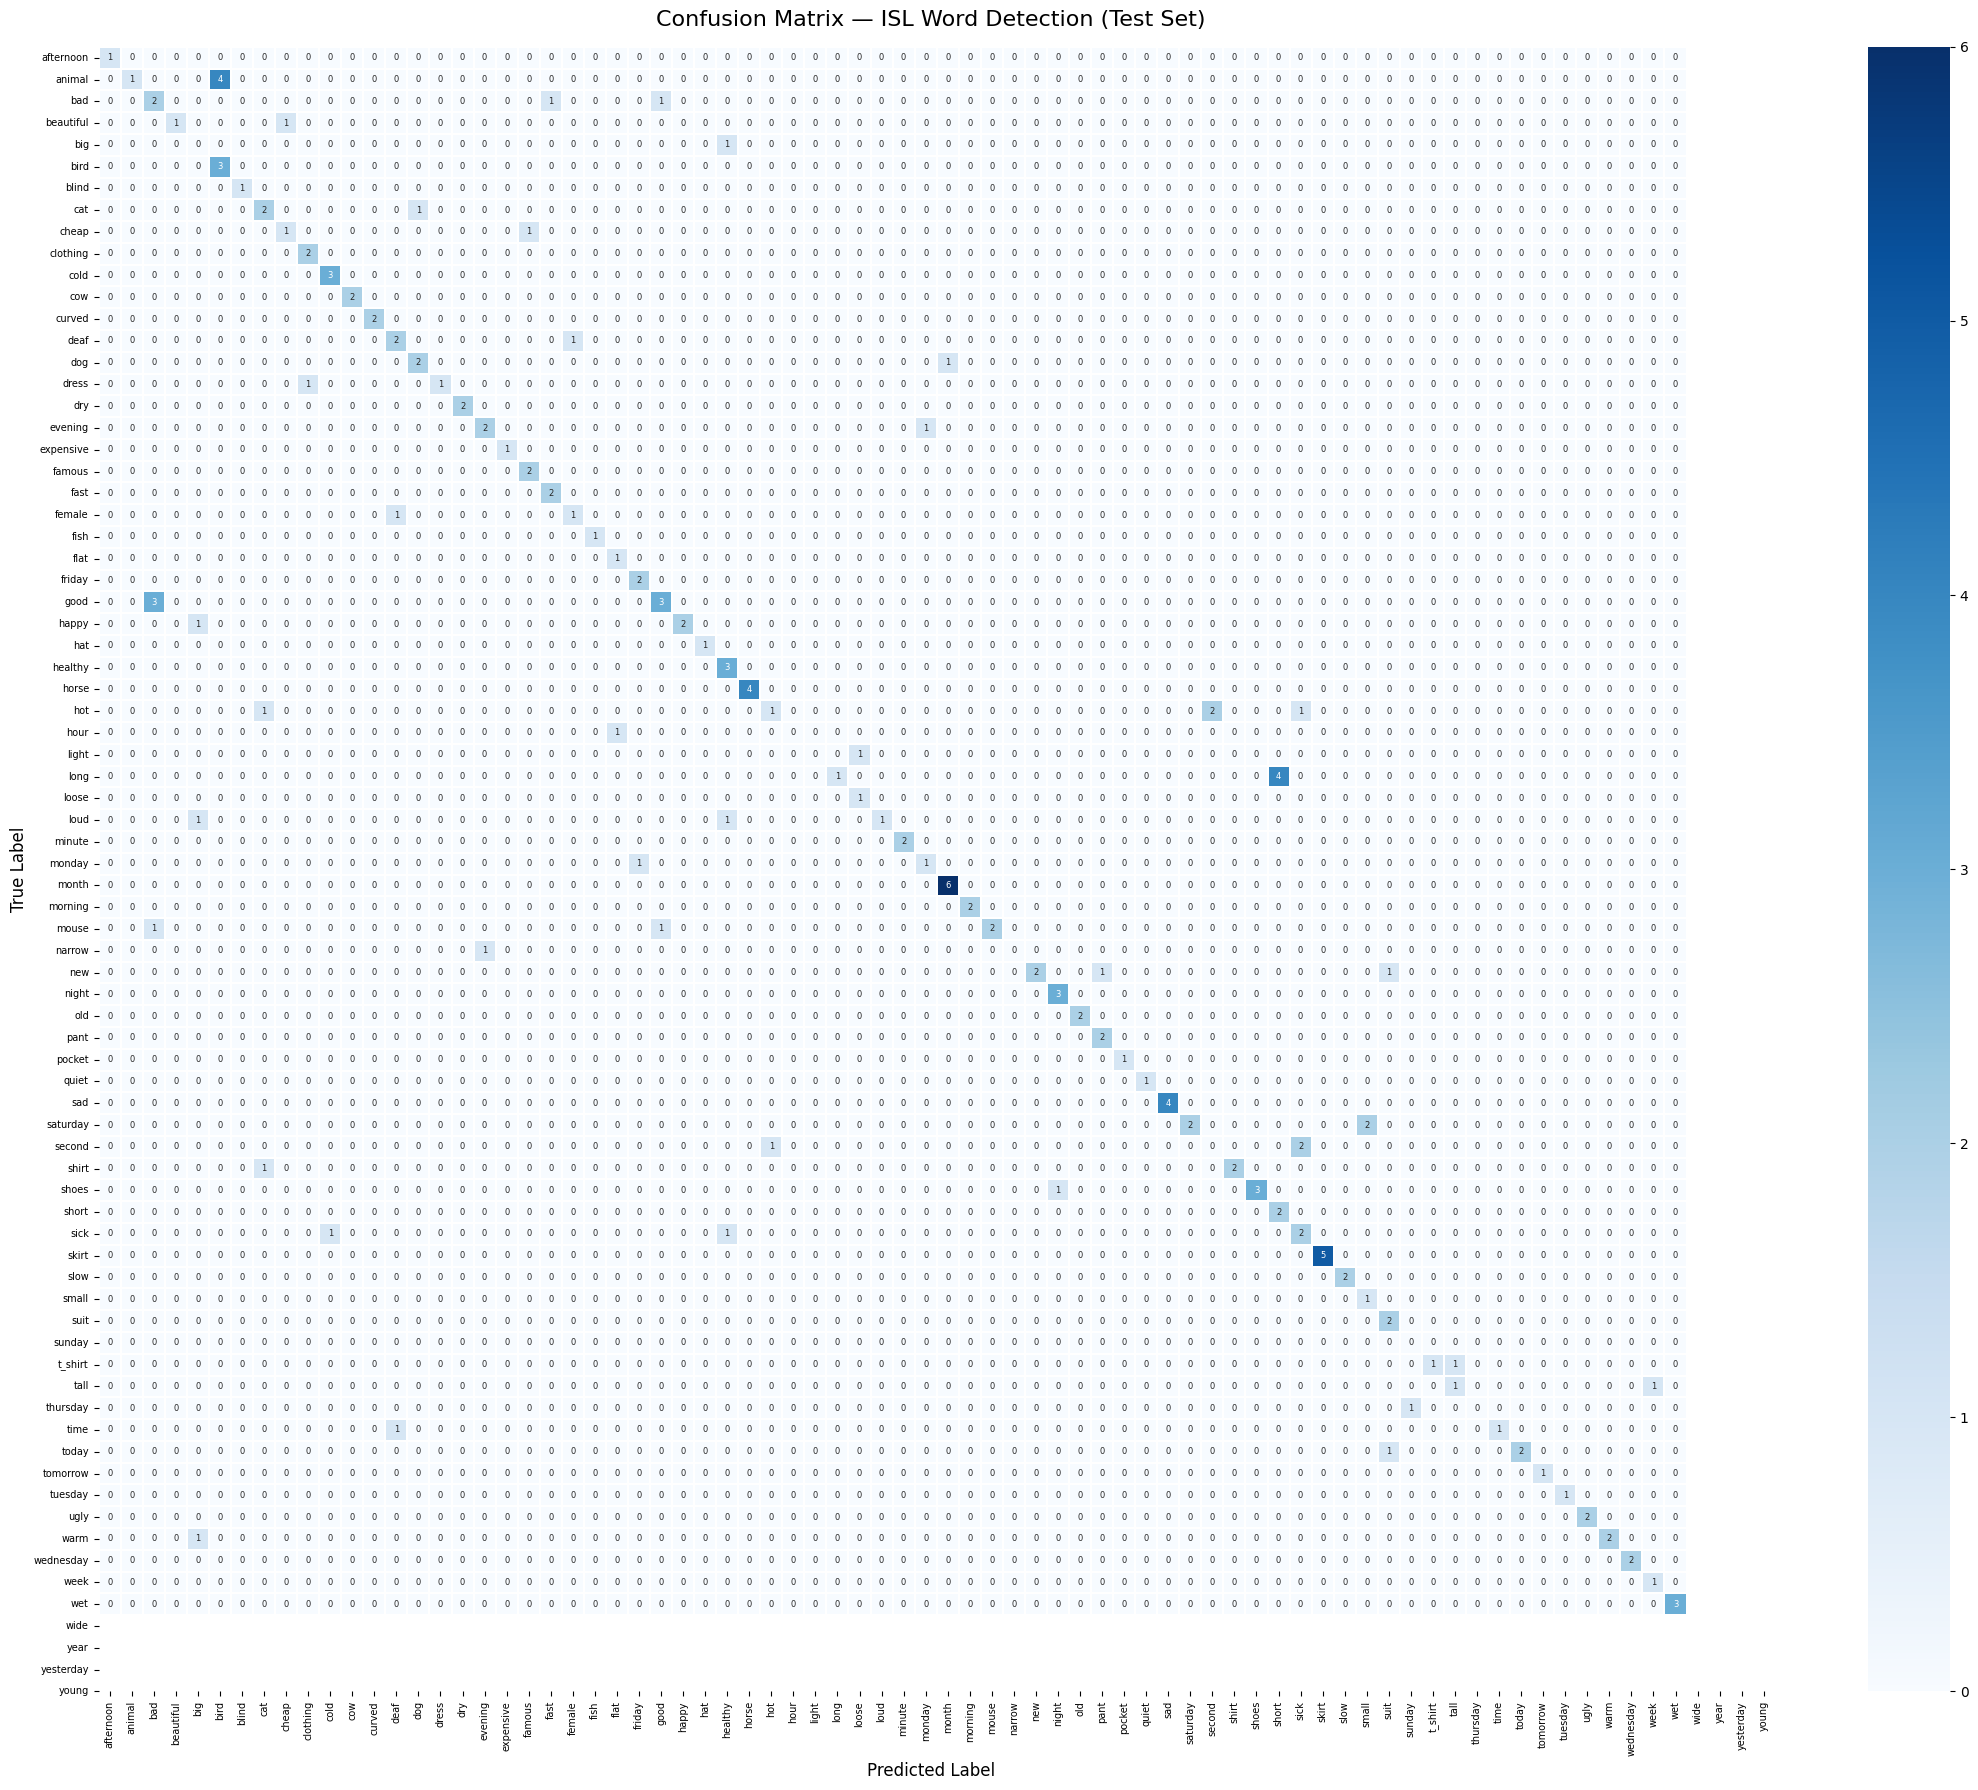

✅ Confusion matrix saved!

📋 Per-Class Classification Report:


ValueError: Number of classes, 72, does not match size of target_names, 76. Try specifying the labels parameter

In [29]:
# ============================================================
# KERNEL 7 — Evaluation Metrics (Accuracy, F1, Confusion Matrix)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)

# ---- Predictions ----
y_train_pred = np.argmax(model.predict(X_train, verbose=0), axis=1)
y_val_pred   = np.argmax(model.predict(X_val,   verbose=0), axis=1)
y_test_pred  = np.argmax(model.predict(X_test,  verbose=0), axis=1)

# ---- Metrics Function ----
def get_metrics(y_true, y_pred, split_name):
    acc = accuracy_score(y_true, y_pred)
    p_mac, r_mac, f1_mac, _ = precision_recall_fscore_support(y_true, y_pred, average='macro',    zero_division=0)
    p_wt,  r_wt,  f1_wt,  _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    print(f"\n{'='*45}")
    print(f"  {split_name}")
    print(f"{'='*45}")
    print(f"  Accuracy          : {acc*100:.2f}%")
    print(f"  Macro    F1-Score : {f1_mac*100:.2f}%")
    print(f"  Weighted F1-Score : {f1_wt*100:.2f}%")
    print(f"  Macro    Precision: {p_mac*100:.2f}%")
    print(f"  Macro    Recall   : {r_mac*100:.2f}%")
    return acc, f1_mac, f1_wt

train_acc, train_f1_mac, train_f1_wt = get_metrics(y_train, y_train_pred, "TRAINING SET")
val_acc,   val_f1_mac,   val_f1_wt   = get_metrics(y_val,   y_val_pred,   "VALIDATION SET")
test_acc,  test_f1_mac,  test_f1_wt  = get_metrics(y_test,  y_test_pred,  "TEST SET")

# ---- Summary Table ----
print(f"\n{'Metric':<25} {'Train':>10} {'Val':>10} {'Test':>10}")
print("-" * 57)
print(f"{'Accuracy':<25} {train_acc*100:>9.2f}% {val_acc*100:>9.2f}% {test_acc*100:>9.2f}%")
print(f"{'Macro F1-Score':<25} {train_f1_mac*100:>9.2f}% {val_f1_mac*100:>9.2f}% {test_f1_mac*100:>9.2f}%")
print(f"{'Weighted F1-Score':<25} {train_f1_wt*100:>9.2f}% {val_f1_wt*100:>9.2f}% {test_f1_wt*100:>9.2f}%")

# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(22, 18))
sns.heatmap(cm,
            annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues',
            linewidths=0.3,
            annot_kws={"size": 6})
plt.title('Confusion Matrix — ISL Word Detection (Test Set)', fontsize=16, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

# ---- Per-class Report ----
print("\n📋 Per-Class Classification Report:")
print(classification_report(y_test, y_test_pred,
                             target_names=le.classes_,
                             zero_division=0))

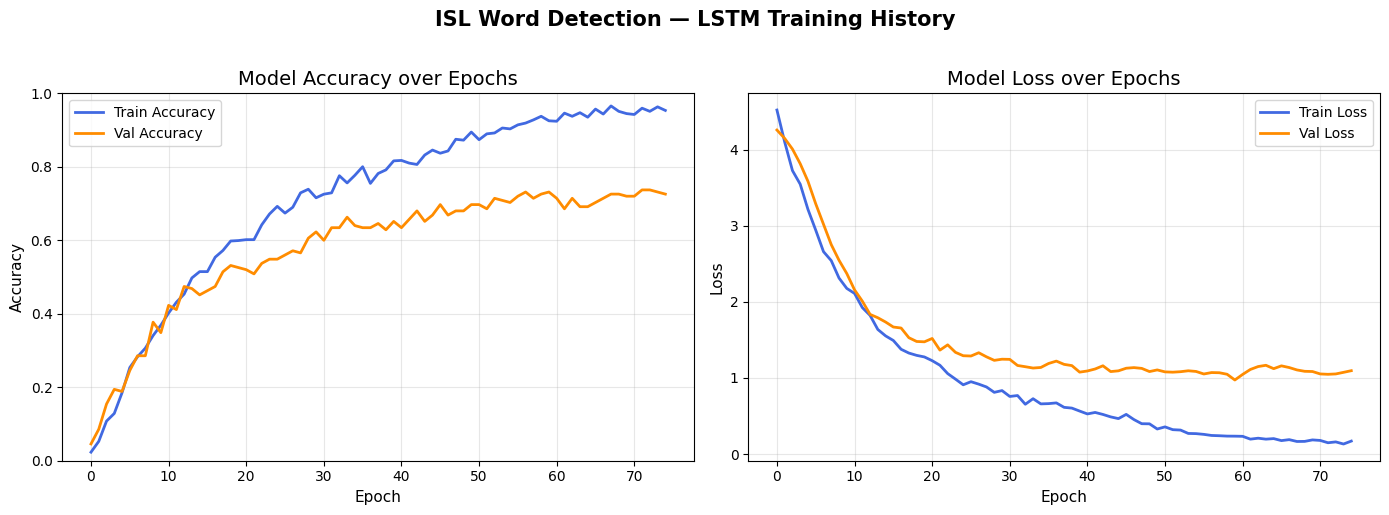

✅ Training plots saved!


In [30]:
# ============================================================
# KERNEL 8 — Training Accuracy & Loss Plots
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Accuracy Plot ----
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='royalblue',  linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='darkorange', linewidth=2)
axes[0].set_title('Model Accuracy over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# ---- Loss Plot ----
axes[1].plot(history.history['loss'],     label='Train Loss', color='royalblue',  linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='darkorange', linewidth=2)
axes[1].set_title('Model Loss over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('ISL Word Detection — LSTM Training History', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/training_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training plots saved!")

In [31]:
# ============================================================
# KERNEL 9 — Save & Download All Files
# ============================================================

import os
from google.colab import files

# Verify all files exist
required_files = [
    '/content/best_model.keras',
    '/content/label_encoder.pkl',
    '/content/norm_mean.npy',
    '/content/norm_std.npy',
]

print("📦 Files ready:")
for f in required_files:
    size = os.path.getsize(f) / 1024
    print(f"  {'✅' if os.path.exists(f) else '❌'} {f}  ({size:.1f} KB)")

# Download everything
print("\n⬇️ Downloading...")
for f in required_files:
    files.download(f)

print("\n✅ All files downloaded!")

📦 Files ready:
  ✅ /content/best_model.keras  (2976.0 KB)
  ✅ /content/label_encoder.pkl  (2.9 KB)
  ✅ /content/norm_mean.npy  (1.9 KB)
  ✅ /content/norm_std.npy  (1.9 KB)

⬇️ Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded!


In [32]:
import numpy as np

mean = np.load('/content/norm_mean.npy')
std  = np.load('/content/norm_std.npy')
print(f"Mean shape: {mean.shape}")   # Must say (1, 1, 292)
print(f"Std shape:  {std.shape}")    # Must say (1, 1, 292)

Mean shape: (1, 1, 225)
Std shape:  (1, 1, 225)
